# 1.Instalar/Importar bibliotecas

In [1]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Configurar visualizações
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2.Carregar o dataset do Kaggle (via UCI)

In [3]:
# Carregar o dataset SMS Spam Collection
# URL direta do repositório UCI (dataset público)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'

# Baixar e ler o arquivo zip
import zipfile
import urllib.request
import io

# Baixar o arquivo
print("Baixando dataset do UCI (fonte original do Kaggle)...")
with urllib.request.urlopen(url) as response:
    zip_data = response.read()

# Extrair e ler o arquivo
with zipfile.ZipFile(io.BytesIO(zip_data)) as z:
    with z.open('SMSSpamCollection') as f:
        df = pd.read_csv(f, sep='\t', names=['label', 'message'], encoding='utf-8')

print(f" Dataset carregado com sucesso!")
print(f"   - Total de mensagens: {df.shape[0]}")
print(f"   - Colunas: {df.shape[1]}")
print("\n Primeiras 5 linhas:")
df.head()

Baixando dataset do UCI (fonte original do Kaggle)...
 Dataset carregado com sucesso!
   - Total de mensagens: 5572
   - Colunas: 2

 Primeiras 5 linhas:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# 3.Análise exploratória dos dados

ANÁLISE EXPLORATÓRIA

 Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

 Valores nulos por coluna:
label      0
message    0
dtype: int64

 Distribuição das classes:
label
ham     4825
spam     747
Name: count, dtype: int64

 Proporção (%):
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


/tmp/ipykernel_8980/3822205996.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette=['green', 'red'])


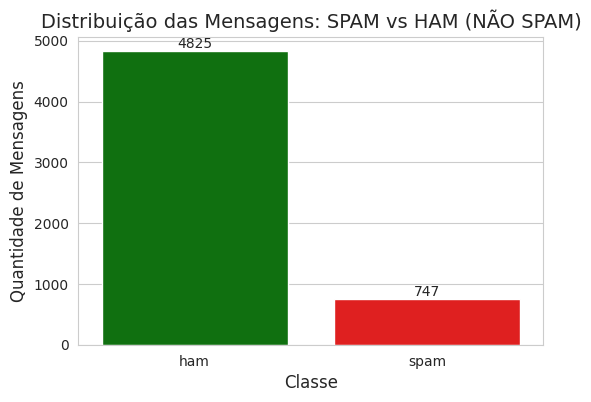


 Estatísticas do comprimento das mensagens:
   - Mensagens HAM (não spam): média = 71.5 caracteres
   - Mensagens SPAM: média = 138.7 caracteres


/tmp/ipykernel_8980/3822205996.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='length', palette=['green', 'red'])


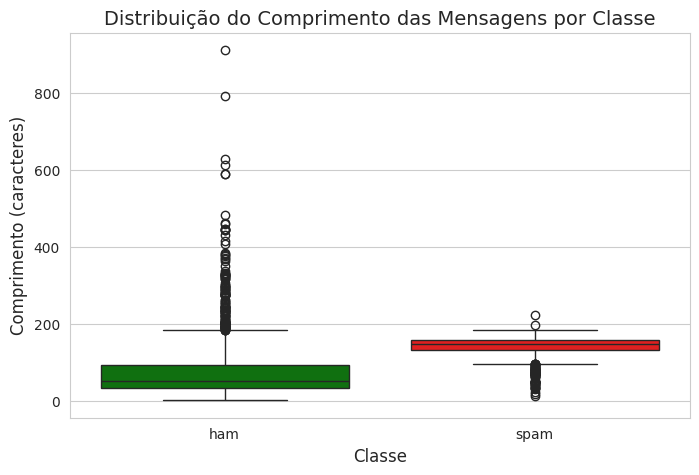

In [4]:
# ============================================
# ANÁLISE EXPLORATÓRIA
# ============================================

print("=" * 50)
print("ANÁLISE EXPLORATÓRIA")
print("=" * 50)

# Verificar informações do dataset
print("\n Informações do dataset:")
print(df.info())

# Verificar valores nulos
print("\n Valores nulos por coluna:")
print(df.isnull().sum())

# Verificar distribuição das classes
print("\n Distribuição das classes:")
print(df['label'].value_counts())
print("\n Proporção (%):")
print(df['label'].value_counts(normalize=True) * 100)

# Visualizar distribuição
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x='label', palette=['green', 'red'])
plt.title('Distribuição das Mensagens: SPAM vs HAM (NÃO SPAM)', fontsize=14)
plt.xlabel('Classe', fontsize=12)
plt.ylabel('Quantidade de Mensagens', fontsize=12)

# Adicionar valores nas barras
for i in ax.containers:
    ax.bar_label(i, label_type='edge')

plt.show()

# Estatísticas sobre o comprimento das mensagens
df['length'] = df['message'].apply(len)
print("\n Estatísticas do comprimento das mensagens:")
print(f"   - Mensagens HAM (não spam): média = {df[df['label']=='ham']['length'].mean():.1f} caracteres")
print(f"   - Mensagens SPAM: média = {df[df['label']=='spam']['length'].mean():.1f} caracteres")

# Boxplot do comprimento por classe
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='label', y='length', palette=['green', 'red'])
plt.title('Distribuição do Comprimento das Mensagens por Classe', fontsize=14)
plt.xlabel('Classe', fontsize=12)
plt.ylabel('Comprimento (caracteres)', fontsize=12)
plt.show()

# 4.Pré-processamento: transformar texto em números

In [6]:
# ============================================
# PRÉ-PROCESSAMENTO
# ============================================

print("=" * 50)
print(" PRÉ-PROCESSAMENTO")
print("=" * 50)

# Converter rótulos: 'spam' = 1, 'ham' = 0
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

print("\n Rótulos convertidos:")
print(df[['label', 'label_num']].head(10))

# Usar TF-IDF Vectorizer (mais robusto que CountVectorizer)
# TF-IDF = Term Frequency - Inverse Document Frequency
# Dá menos peso para palavras muito comuns (ex: "de", "a", "o")
vectorizer = TfidfVectorizer(
    max_features=5000,           # Usar as 5000 palavras mais importantes
    stop_words='english',        # Remover palavras comuns em inglês (ex: the, and, to)
    ngram_range=(1, 2)           # Considerar palavras isoladas e pares de palavras
)

# Transformar as mensagens em uma matriz de números
X = vectorizer.fit_transform(df['message']).toarray()
y = df['label_num'].values

print(f"\n Matriz de características criada!")
print(f"   - Número de amostras: {X.shape[0]}")
print(f"   - Número de palavras/pares de palavras: {X.shape[1]}")
print(f"\n📝 Exemplo de palavras importantes identificadas:")
print(f"   {list(vectorizer.get_feature_names_out()[:20])}...")

 PRÉ-PROCESSAMENTO

 Rótulos convertidos:
  label  label_num
0   ham          0
1   ham          0
2  spam          1
3   ham          0
4   ham          0
5  spam          1
6   ham          0
7   ham          0
8  spam          1
9  spam          1

 Matriz de características criada!
   - Número de amostras: 5572
   - Número de palavras/pares de palavras: 5000

📝 Exemplo de palavras importantes identificadas:
   ['00', '00 sub', '00 subs', '000', '000 bonus', '000 cash', '000 homeowners', '000 pounds', '000 prize', '000 xmas', '01223585334 cum', '02', '02 06', '02 09', '0207', '03', '03 2nd', '04', '05', '06']...


# 5.Dividir em treino e teste

In [7]:
# ============================================
# DIVISÃO TREINO/TESTE
# ============================================

print("=" * 50)
print("DIVISÃO TREINO/TESTE")
print("=" * 50)

# Dividir os dados: 80% treino, 20% teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Dados divididos:")
print(f"   - Treino: {X_treino.shape[0]} mensagens ({X_treino.shape[0]/len(y)*100:.1f}%)")
print(f"   - Teste: {X_teste.shape[0]} mensagens ({X_teste.shape[0]/len(y)*100:.1f}%)")

print(f"\n Distribuição das classes em cada conjunto:")
print(f"   Treino - HAM: {sum(y_treino==0)} | SPAM: {sum(y_treino==1)}")
print(f"   Teste  - HAM: {sum(y_teste==0)} | SPAM: {sum(y_teste==1)}")

DIVISÃO TREINO/TESTE

 Dados divididos:
   - Treino: 4457 mensagens (80.0%)
   - Teste: 1115 mensagens (20.0%)

 Distribuição das classes em cada conjunto:
   Treino - HAM: 3859 | SPAM: 598
   Teste  - HAM: 966 | SPAM: 149


# 6.Treinar o modelo de Regressão Logística

In [8]:
# ============================================
# TREINAMENTO DO MODELO
# ============================================

print("=" * 50)
print("TREINAMENTO DO MODELO")
print("=" * 50)

# Criar e treinar o modelo de Regressão Logística
modelo = LogisticRegression(
    max_iter=1000,      # Número máximo de iterações
    random_state=42,    # Garantir reprodutibilidade
    C=1.0,              # Parâmetro de regularização (padrão)
    solver='lbfgs'      # Algoritmo de otimização
)

print("\n Treinando o modelo...")
modelo.fit(X_treino, y_treino)
print("Modelo treinado com sucesso!")

# Coeficientes do modelo (importância de cada palavra)
print(f"\n📊 Coeficientes do modelo:")
print(f"   - Número de features: {len(modelo.coef_[0])}")
print(f"   - Feature mais importante: {vectorizer.get_feature_names_out()[modelo.coef_[0].argmax()]}")

TREINAMENTO DO MODELO

 Treinando o modelo...
Modelo treinado com sucesso!

📊 Coeficientes do modelo:
   - Número de features: 5000
   - Feature mais importante: txt


# 7.Fazer previsões e avaliar o modelo

In [9]:
# ============================================
# AVALIAÇÃO DO MODELO
# ============================================

print("=" * 50)
print(" AVALIAÇÃO DO MODELO")
print("=" * 50)

# Fazer previsões no conjunto de teste
predicoes = modelo.predict(X_teste)
probabilidades = modelo.predict_proba(X_teste)

# Calcular métricas
acuracia = accuracy_score(y_teste, predicoes)
precisao = precision_score(y_teste, predicoes)
recall = recall_score(y_teste, predicoes)
f1 = f1_score(y_teste, predicoes)

print(f"\n RESULTADOS:")
print(f"   ┌{'─'*40}┐")
print(f"   │ Acurácia:  {acuracia:.4f} ({acuracia*100:.2f}%)")
print(f"   │ Precisão:  {precisao:.4f} ({precisao*100:.2f}%)")
print(f"   │ Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"   │ F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
print(f"   └{'─'*40}┘")

# Relatório de classificação completo
print(f"\n📋 Relatório de Classificação:")
print(classification_report(y_teste, predicoes, target_names=['HAM (NÃO SPAM)', 'SPAM']))

 AVALIAÇÃO DO MODELO

 RESULTADOS:
   ┌────────────────────────────────────────┐
   │ Acurácia:  0.9659 (96.59%)
   │ Precisão:  1.0000 (100.00%)
   │ Recall:    0.7450 (74.50%)
   │ F1-Score:  0.8538 (85.38%)
   └────────────────────────────────────────┘

📋 Relatório de Classificação:
                precision    recall  f1-score   support

HAM (NÃO SPAM)       0.96      1.00      0.98       966
          SPAM       1.00      0.74      0.85       149

      accuracy                           0.97      1115
     macro avg       0.98      0.87      0.92      1115
  weighted avg       0.97      0.97      0.96      1115



# 8.Matriz de confusão

MATRIZ DE CONFUSÃO

 Matriz de Confusão:
                      Previsto: HAM (Não Spam)  Previsto: SPAM
Real: HAM (Não Spam)                       966               0
Real: SPAM                                  38             111

Interpretação:
   ✅ Verdadeiros Positivos (VP): 111 - spams detectados corretamente
   ✅ Verdadeiros Negativos (VN): 966 - não spams corretamente identificados
   ❌ Falsos Positivos (FP): 0 - mensagens boas que foram para o spam
   ❌ Falsos Negativos (FN): 38 - spams que escaparam para a caixa de entrada


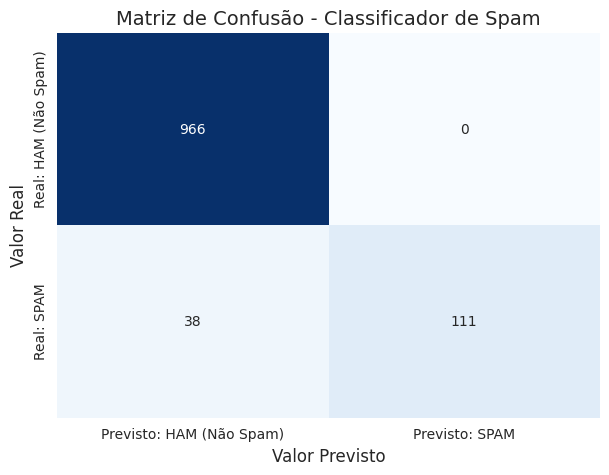

In [10]:
# ============================================
# MATRIZ DE CONFUSÃO
# ============================================

print("=" * 50)
print("MATRIZ DE CONFUSÃO")
print("=" * 50)

# Calcular matriz de confusão
matriz = confusion_matrix(y_teste, predicoes)

# Criar DataFrame para visualização
df_matriz = pd.DataFrame(matriz,
                         index=['Real: HAM (Não Spam)', 'Real: SPAM'],
                         columns=['Previsto: HAM (Não Spam)', 'Previsto: SPAM'])

print("\n Matriz de Confusão:")
print(df_matriz)
print()

# Interpretação
vp = matriz[1, 1]  # Verdadeiro Positivo
vn = matriz[0, 0]  # Verdadeiro Negativo
fp = matriz[0, 1]  # Falso Positivo
fn = matriz[1, 0]  # Falso Negativo

print("Interpretação:")
print(f"   ✅ Verdadeiros Positivos (VP): {vp} - spams detectados corretamente")
print(f"   ✅ Verdadeiros Negativos (VN): {vn} - não spams corretamente identificados")
print(f"   ❌ Falsos Positivos (FP): {fp} - mensagens boas que foram para o spam")
print(f"   ❌ Falsos Negativos (FN): {fn} - spams que escaparam para a caixa de entrada")

# Visualizar matriz de confusão
plt.figure(figsize=(7,5))
sns.heatmap(df_matriz, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão - Classificador de Spam', fontsize=14)
plt.ylabel('Valor Real', fontsize=12)
plt.xlabel('Valor Previsto', fontsize=12)
plt.show()

# 9.Palavras mais importantes para identificar spam

PALAVRAS MAIS IMPORTANTES

📈 TOP 10 palavras que MAIS indicam SPAM:
   txt             -> coeficiente: 4.3892
   mobile          -> coeficiente: 3.5224
   uk              -> coeficiente: 3.5069
   claim           -> coeficiente: 3.4497
   www             -> coeficiente: 3.2919
   reply           -> coeficiente: 3.1357
   stop            -> coeficiente: 2.9861
   service         -> coeficiente: 2.8433
   150p            -> coeficiente: 2.7830
   free            -> coeficiente: 2.7513

📉 TOP 10 palavras que MAIS indicam HAM (NÃO SPAM):
   ok              -> coeficiente: -1.8361
   ll              -> coeficiente: -1.6174
   da              -> coeficiente: -1.4707
   come            -> coeficiente: -1.4199
   gt              -> coeficiente: -1.4046
   home            -> coeficiente: -1.3866
   lt              -> coeficiente: -1.3864
   got             -> coeficiente: -1.3467
   lor             -> coeficiente: -1.2511
   sorry           -> coeficiente: -1.2394


/tmp/ipykernel_8980/2346329204.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancia_spam, y='palavra', x='coeficiente', ax=axes[0], palette='Reds_r')
/tmp/ipykernel_8980/2346329204.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancia_ham, y='palavra', x='coeficiente', ax=axes[1], palette='Greens_r')


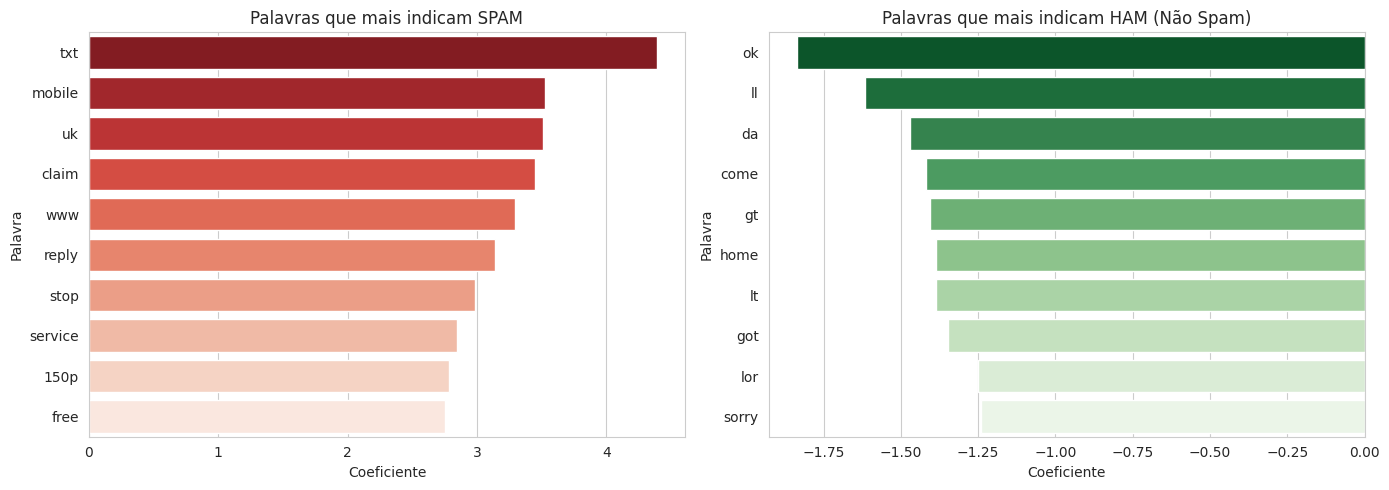

In [11]:
# ============================================
# PALAVRAS MAIS IMPORTANTES PARA DETECTAR SPAM
# ============================================

print("=" * 50)
print("PALAVRAS MAIS IMPORTANTES")
print("=" * 50)

# Pegar os coeficientes do modelo (quanto maior, mais indica SPAM)
coeficientes = modelo.coef_[0]
palavras = vectorizer.get_feature_names_out()

# Criar DataFrame com palavras e coeficientes
importancia = pd.DataFrame({
    'palavra': palavras,
    'coeficiente': coeficientes
})

# Ordenar por importância para spam
importancia_spam = importancia.sort_values('coeficiente', ascending=False).head(10)
importancia_ham = importancia.sort_values('coeficiente', ascending=True).head(10)

print("\n📈 TOP 10 palavras que MAIS indicam SPAM:")
for i, row in importancia_spam.iterrows():
    print(f"   {row['palavra']:15} -> coeficiente: {row['coeficiente']:.4f}")

print("\n📉 TOP 10 palavras que MAIS indicam HAM (NÃO SPAM):")
for i, row in importancia_ham.iterrows():
    print(f"   {row['palavra']:15} -> coeficiente: {row['coeficiente']:.4f}")

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico para spam
sns.barplot(data=importancia_spam, y='palavra', x='coeficiente', ax=axes[0], palette='Reds_r')
axes[0].set_title('Palavras que mais indicam SPAM', fontsize=12)
axes[0].set_xlabel('Coeficiente')
axes[0].set_ylabel('Palavra')

# Gráfico para ham
sns.barplot(data=importancia_ham, y='palavra', x='coeficiente', ax=axes[1], palette='Greens_r')
axes[1].set_title('Palavras que mais indicam HAM (Não Spam)', fontsize=12)
axes[1].set_xlabel('Coeficiente')
axes[1].set_ylabel('Palavra')

plt.tight_layout()
plt.show()

# 10.Testar com mensagens novas (criadas)

In [12]:
# ============================================
# TESTE COM MENSAGENS NOVAS
# ============================================

print("=" * 60)
print("TESTE COM MENSAGENS NOVAS (Exemplos criados para teste)")
print("=" * 60)

# Lista de mensagens para testar
mensagens_teste = [
    # Spams típicos
    "CONGRATULATIONS! You've won a FREE iPhone 15! Click here to claim your prize now!",
    "URGENT: Your PayPal account has been limited. Verify your identity immediately at this link.",
    "You are the lucky winner of our lottery! Send $100 to receive your $10,000 prize!",
    "DEAR CUSTOMER: Your bank account has been compromised. Please call this number urgently.",

    # Hams (mensagens normais)
    "Hey mom, I'll be home for dinner at 7pm. Love you!",
    "Reminder: Our meeting tomorrow at 10am in the conference room.",
    "Hi John, can you please send me the report by Friday? Thanks!",
    "Don't forget to buy milk and bread on your way home.",

    # Casos borderline
    "FREE entry to our contest! Visit our website for details.",
    "Your package has been shipped and will arrive tomorrow."
]

# Transformar as mensagens em números usando o mesmo vetorizador
mensagens_vetorizadas = vectorizer.transform(mensagens_teste)

# Fazer previsões
previsoes = modelo.predict(mensagens_vetorizadas)
probabilidades = modelo.predict_proba(mensagens_vetorizadas)

# Exibir resultados
for i, (msg, pred, prob) in enumerate(zip(mensagens_teste, previsoes, probabilidades)):
    classe = "🔴 SPAM" if pred == 1 else "🟢 HAM (NÃO SPAM)"
    prob_spam = prob[1] * 100
    prob_ham = prob[0] * 100

    print(f"\n Mensagem {i+1}:")
    print(f"   Texto: {msg[:70]}{'...' if len(msg) > 70 else ''}")
    print(f"   Classificação: {classe}")
    print(f"   Probabilidade de ser SPAM: {prob_spam:.2f}%")
    print(f"   Probabilidade de ser HAM: {prob_ham:.2f}%")
    print("-" * 60)

TESTE COM MENSAGENS NOVAS (Exemplos criados para teste)

 Mensagem 1:
   Texto: CONGRATULATIONS! You've won a FREE iPhone 15! Click here to claim your...
   Classificação: 🔴 SPAM
   Probabilidade de ser SPAM: 69.73%
   Probabilidade de ser HAM: 30.27%
------------------------------------------------------------

 Mensagem 2:
   Texto: URGENT: Your PayPal account has been limited. Verify your identity imm...
   Classificação: 🟢 HAM (NÃO SPAM)
   Probabilidade de ser SPAM: 36.40%
   Probabilidade de ser HAM: 63.60%
------------------------------------------------------------

 Mensagem 3:
   Texto: You are the lucky winner of our lottery! Send $100 to receive your $10...
   Classificação: 🔴 SPAM
   Probabilidade de ser SPAM: 59.51%
   Probabilidade de ser HAM: 40.49%
------------------------------------------------------------

 Mensagem 4:
   Texto: DEAR CUSTOMER: Your bank account has been compromised. Please call thi...
   Classificação: 🟢 HAM (NÃO SPAM)
   Probabilidade de ser SPAM: 

# 11. Respostas da Atividade (Semana 10)

**Qual foi a acurácia, precisão e recall obtidos?**
Acurácia de 96,59%, precisão de 100% e recall de 74,50% (F1-score de 85,38%).

**O que cada métrica significa neste contexto (spam)?**
A acurácia mede o percentual geral de mensagens classificadas corretamente; a precisão mede, das mensagens marcadas como spam, quantas realmente eram spam (aqui, todas); e o recall mede, de todos os spams reais, quantos o modelo conseguiu detectar (aqui, cerca de 3 em cada 4).

**Para um filtro de spam, qual métrica você acha mais importante? Por quê?**
A precisão é a mais importante, pois um falso positivo (e-mail bom indo para o spam) pode fazer o usuário perder uma mensagem importante, o que é geralmente mais prejudicial do que deixar passar algum spam (falso negativo).
